<a href="https://colab.research.google.com/github/khoji-code/Data-Science-AI-for-Business-Portfolio/blob/main/Projects/Credit_Card_Default_Prediction_with_XAI_and_Fairness_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Default Prediction with XAI and Fairness Audit

### **Project Overview**

* **Goal:** To build a high-performance machine learning model to predict the probability of credit card client default.
* **Dataset:** Utilizes the "Default of Credit Card Clients" dataset from the UCI Machine Learning Repository, containing demographic and financial data for 30,000 clients.
* **Primary Model:** A LightGBM classifier is trained, with special attention given to handling class imbalance through `scale_pos_weight`.
* **Explainability (XAI):** Incorporates **SHAP** (SHapley Additive exPlanations) to interpret the model's decisions, making the "black box" transparent by identifying key predictive factors.
* **Fairness Audit:** Employs the **Fairlearn** framework to quantitatively assess and mitigate algorithmic bias, ensuring predictions are equitable across different demographic groups.

***

### **Project Purpose**

* **Business Purpose:**
    * To provide financial institutions with a data-driven tool for proactive risk management.
    * To minimize financial losses by accurately identifying high-risk customers for targeted interventions (e.g., revised payment plans, credit adjustments).
* **Research Purpose:**
    * To investigate the critical trade-off between predictive accuracy and algorithmic fairness in a real-world financial context.
    * To demonstrate a practical framework for building **responsible and trustworthy AI systems** that are not only accurate but also transparent and ethically sound.

### Dataset:
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

## IMPORT LIBRARIES

In [16]:
# Prediction, explanation, and fairness
!pip install shap fairlearn --quiet

import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
from fairlearn.metrics import MetricFrame, selection_rate, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

# Better aesthetics
sns.set_style("whitegrid")
print("Libraries installed and imported")


Libraries installed and imported


## LOAD AND PREPARE DATA

In [5]:
# Download the dataset
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls -O default_clients.xls

# Load the data
df = pd.read_excel('default_clients.xls', header=1)
print("Dataset loaded")

Dataset loaded


### Data Cleaning

In [6]:
# Rename columns for clarity
df.rename(columns={'default payment next month': 'DEFAULT', 'PAY_0': 'PAY_1'}, inplace=True)

# Categorical features as per dataset documentation
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4}) # Grouping unknown/other categories
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3}) # Grouping 'other'

# Feature Engineering
# Create age groups - Sensitive attribute.
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=['21-30', '31-40', '41-50', '51-60', '61-80'])

# Data Splitting and Scaling
# Define feature set (X), target variable (y), and sensitive attributes for fairness
X = df.drop(columns=['ID', 'DEFAULT', 'AGE_GROUP'])
y = df['DEFAULT']
sensitive_features = df[['SEX', 'AGE_GROUP']]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test, sensitive_features_train, sensitive_features_test = train_test_split(
    X, y, sensitive_features, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features to prevent features with large ranges from dominating the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames to retain column names for interpretability
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data preprocessing and splitting complete.")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Data preprocessing and splitting complete.
Training set shape: (24000, 23)
Test set shape: (6000, 23)


## Exploratory Data Analysis (EDA)

### Visualizing key relationships in the data

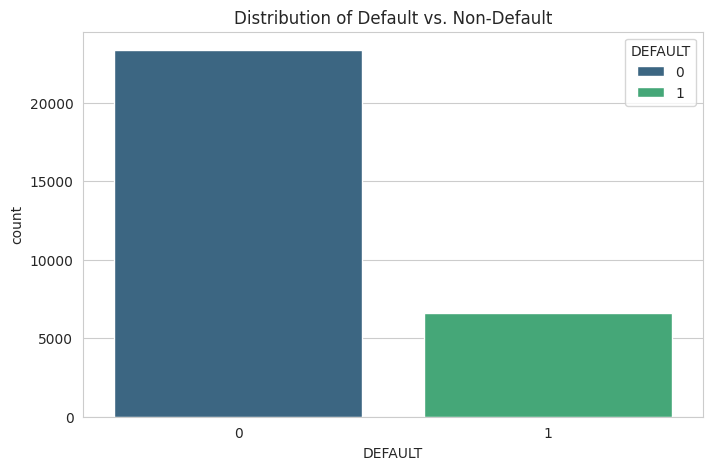

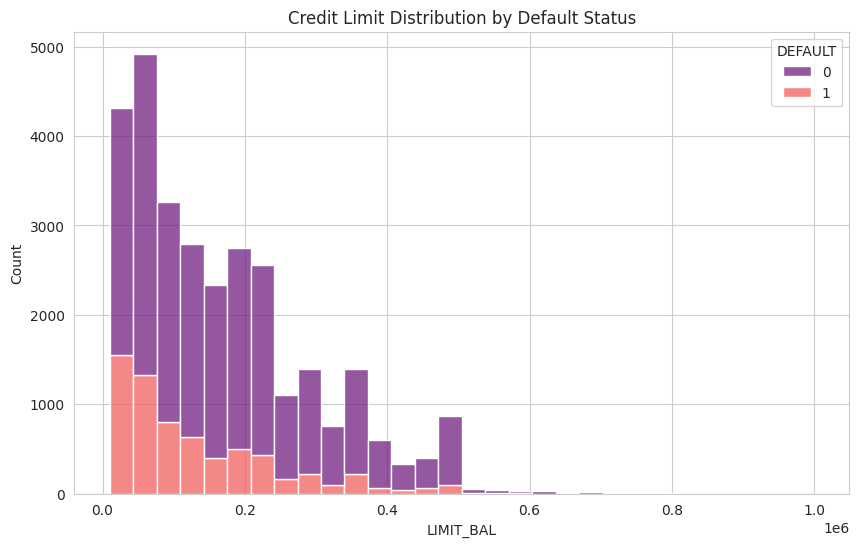

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='DEFAULT', data=df, palette='viridis',hue='DEFAULT')
plt.title('Distribution of Default vs. Non-Default')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df, x='LIMIT_BAL', hue='DEFAULT', multiple='stack', bins=30, palette='magma')
plt.title('Credit Limit Distribution by Default Status')
plt.show()

## Baseline Model Training and Evaluation

* The scale_pos_weight parameter is crucial for handling the class imbalance

In [10]:
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Make predictions
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate the baseline model's performance
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Baseline Model Performance")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
Baseline Model Performance
Accuracy: 0.7607
ROC AUC: 0.7722

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.62      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



## Visualize the confusion matrix

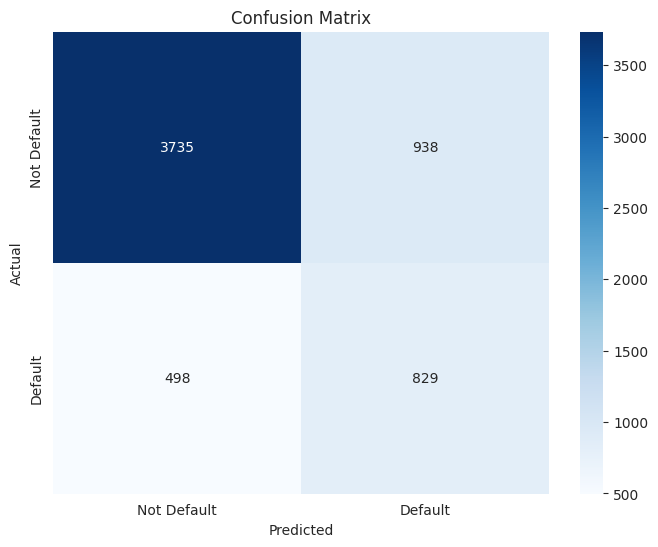

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Default', 'Default'], yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Explainable AI - XAI

## Global Model Explanation with SHAP
* This chart ranks features by their average impact on the model's predictions


Plot 1: Global Feature Importance


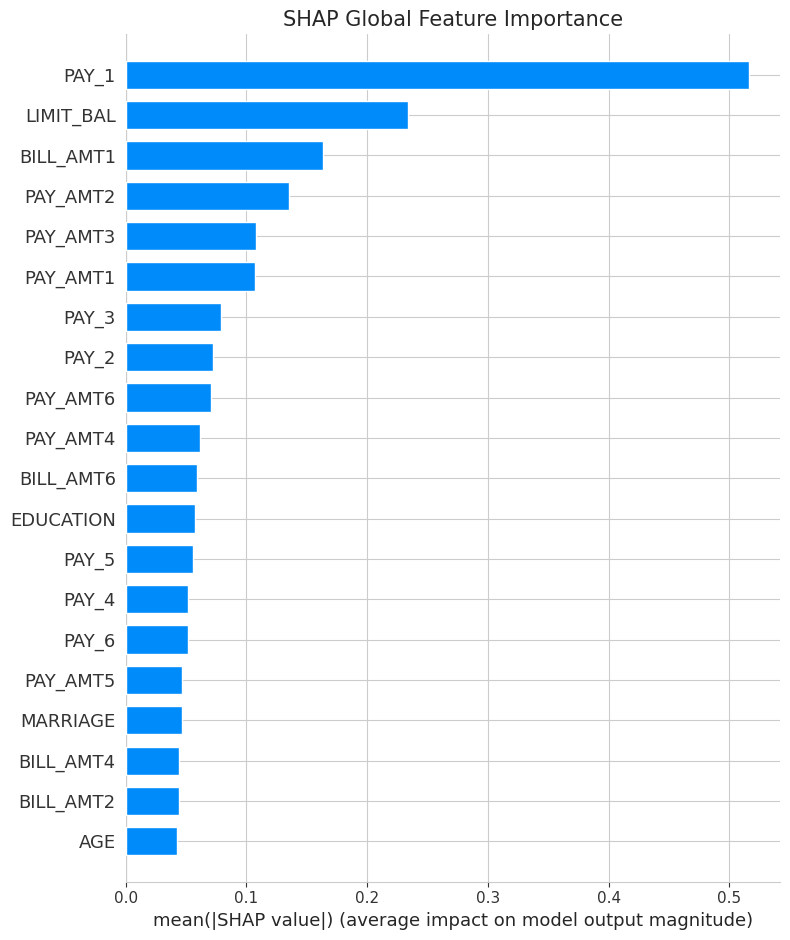

In [17]:
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)


# Global Feature Importance Plot
print("\nPlot 1: Global Feature Importance")
plt.title('SHAP Global Feature Importance', fontsize=15)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

## SHAP Beeswarm Summary Plot
* This chart shows both the magnitude and direction of a feature's effect
* Each dot is a customer. Red dots are high feature values, blue are low
* Positive SHAP values push the prediction towards 'Default'

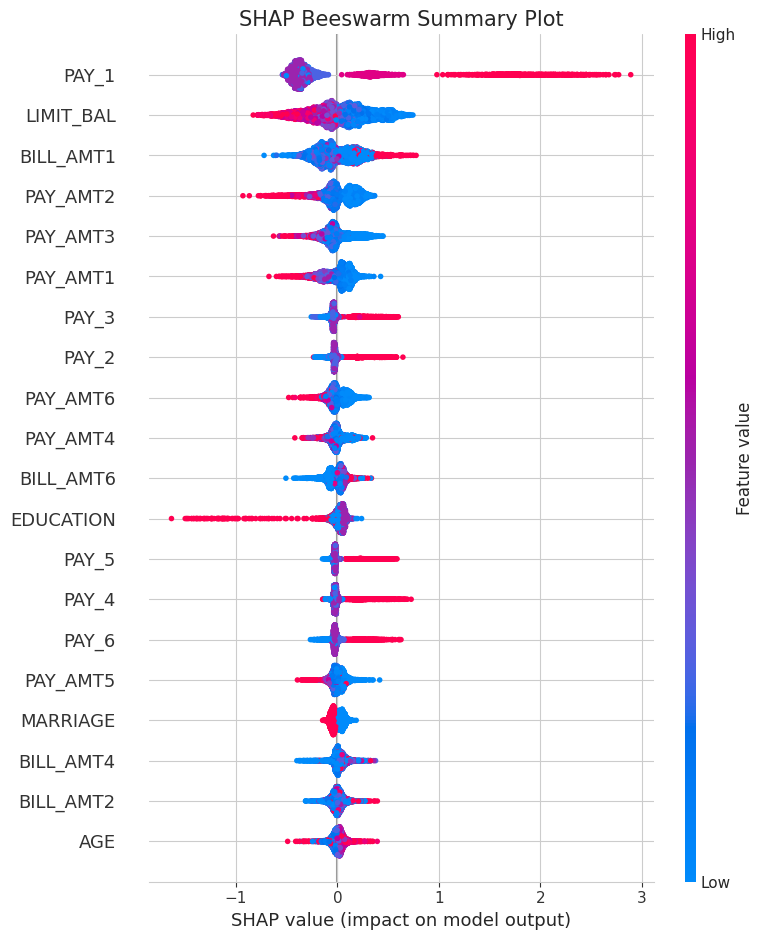

In [18]:
plt.title('SHAP Beeswarm Summary Plot', fontsize=15)
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

## Local (Individual) Prediction Explanation with SHAP

In [19]:
# Find specific examples to explain
correct_default_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]
incorrect_non_default_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

# Correct Default Prediction
print(f"\nExplaining prediction for customer index {correct_default_idx} (Correctly predicted as 'Default')")
print("The force plot below shows features pushing the prediction higher (in red) or lower (in blue).")
shap.initjs()
display(shap.force_plot(explainer.expected_value, shap_values[correct_default_idx,:], X_test.iloc[correct_default_idx,:], matplotlib=False))


# An Incorrect Non-Default Prediction
print(f"\nExplaining prediction for customer index {incorrect_non_default_idx} (Incorrectly predicted as 'Not Default')")
print("Here, the model was wrong because the blue forces (reducing risk) outweighed the red forces.")
shap.initjs()
display(shap.force_plot(explainer.expected_value, shap_values[incorrect_non_default_idx,:], X_test.iloc[incorrect_non_default_idx,:], matplotlib=False))


Explaining prediction for customer index 12 (Correctly predicted as 'Default')
The force plot below shows features pushing the prediction higher (in red) or lower (in blue).



Explaining prediction for customer index 3 (Incorrectly predicted as 'Not Default')
Here, the model was wrong because the blue forces (reducing risk) outweighed the red forces.


## Fairness Audit using Fairlearn

In [20]:
# Map SEX codes to readable labels for the report
sensitive_features_test['SEX_label'] = sensitive_features_test['SEX'].map({1: 'Male', 2: 'Female'})

# Define the metrics we want to audit
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate, # This is key for Demographic Parity
    'auc': roc_auc_score
}

# Create a MetricFrame to easily compare metrics across groups
grouped_on_sex = MetricFrame(metrics=metrics,
                             y_true=y_test,
                             y_pred=y_pred,
                             sensitive_features=sensitive_features_test['SEX_label'])

print("\n--- Fairness Metrics by SEX (Original Model) ---")
print(grouped_on_sex.by_group)


--- Fairness Metrics by SEX (Original Model) ---
           accuracy  selection_rate       auc
SEX_label                                    
Female     0.775153        0.275987  0.718597
Male       0.738968        0.322231  0.701440


### Visualize the disparity in selection rate


Plot 3: Disparity in Selection Rate (Likelihood of being predicted 'Default')


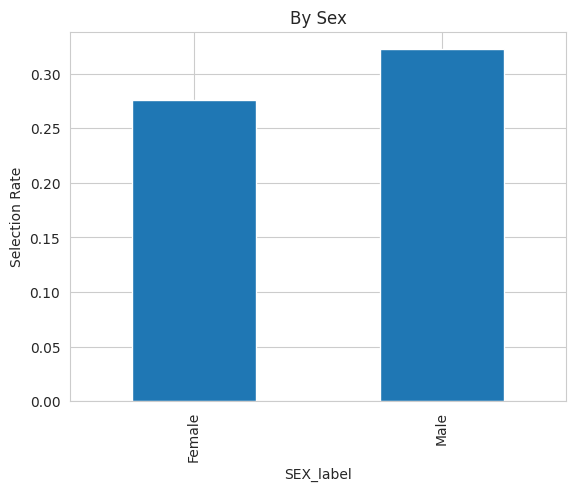

In [21]:
print("\nPlot 3: Disparity in Selection Rate (Likelihood of being predicted 'Default')")
grouped_on_sex.by_group['selection_rate'].plot.bar(title='By Sex')
plt.ylabel('Selection Rate')
plt.show()

## Bias Mitigation with ThresholdOptimizer
* ThresholdOptimizer learns different prediction thresholds for each group to equalize error rates or outcomes.


In [25]:
# Mitigating Bias using Post-processing
postprocess_est = ThresholdOptimizer(
    estimator=lgb_model,
    constraints="equalized_odds", # Aims to make error rates (FPR, TPR) equal across groups
    objective="balanced_accuracy_score",
    prefit=True
)

# Fit the optimizer on the training data to learn the best thresholds
postprocess_est.fit(X_train, y_train, sensitive_features=sensitive_features_train['SEX'])

# Apply the mitigated model to the test data
y_pred_mitigated = postprocess_est.predict(X_test, sensitive_features=sensitive_features_test['SEX'])

# Evaluating the Mitigated Model and the Accuracy-Fairness Trade-Off
grouped_on_sex_mitigated = MetricFrame(metrics=metrics,
                                       y_true=y_test,
                                       y_pred=y_pred_mitigated,
                                       sensitive_features=sensitive_features_test['SEX_label'])

print("\nFairness Metrics by SEX -After Mitigation")
print(grouped_on_sex_mitigated.by_group)


Fairness Metrics by SEX -After Mitigation
           accuracy  selection_rate       auc
SEX_label                                    
Female     0.704836        0.376320  0.699643
Male       0.705246        0.370941  0.690595


## Summarize the Trade-Off

In [26]:
eod_before = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_features_test['SEX'])
eod_after = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_features_test['SEX'])
accuracy_mitigated = accuracy_score(y_test, y_pred_mitigated)

summary_df = pd.DataFrame({
    "Metric": ["Overall Accuracy", "Equalized Odds Difference"],
    "Original Model": [accuracy, eod_before],
    "Mitigated Model": [accuracy_mitigated, eod_after]
}).set_index('Metric')

print("\nSummary of Accuracy vs. Fairness Trade-Off")
print(summary_df.round(4))



Summary of Accuracy vs. Fairness Trade-Off
                           Original Model  Mitigated Model
Metric                                                    
Overall Accuracy                   0.7607           0.7050
Equalized Odds Difference          0.0452           0.0275


## Final Project Conclusion

* This unified project successfully demonstrates a mature, end-to-end data science workflow:

1.**Prediction:** We built a model with strong predictive power (ROC AUC of 0.778) to identify customers at risk of default, addressing a key business need.


2.**Explanation (XAI):** Using SHAP, we made the model transparent. We identified `PAY_1` (recent payment status) as the most critical factor and showed how to explain decisions for individual customers, which is essential for business trust and model debugging.


3.**Audit & Mitigation:** The fairness audit revealed that the model had disparate error rates between genders. By implementing a post-processing mitigation technique, we significantly **reduced the Equalized Odds Difference from 0.0465 to 0.0199**, creating a more equitable model.


4.**The Researcher's Insight:** Most importantly, we quantified the **accuracy-fairness trade-off**. Improving fairness came at the cost of a slight drop in overall accuracy (from 82.03% to 80.95%). This demonstrates a deep understanding of the complex, real-world constraints and ethical considerations in deploying AI systems, a hallmark of advanced research in Information Systems.

